# SVM: Face Recognition Application
## This notebook outlines the application of Support Vector Machine in the field of Face Recognition

## Task Requirements
- Import the required packages
- Load the dataset from sklearn.datasets fetch_lfw_people
- Explore the data
- Plot some sample images
- Import SVC
- Apply PCA to reduce the components
- Build a SVM Classifier on the reduced data
- Make a pipeline with pca and svc as stages
- Build the model
- Apply the model
- Plot the Accuracy
- Plot Classification Report
- Plot Confusion Matrix

### Import required packages

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

### Import fetch_lfw_people from sklearn's built-in dataset

In [2]:
from sklearn.datasets import fetch_lfw_people

### Load the faces dataset

In [3]:
faces = fetch_lfw_people(min_faces_per_person=60)

In [4]:
faces

{'data': array([[138.        , 135.66667   , 127.666664  , ...,   1.6666666 ,
           1.6666666 ,   0.33333334],
        [ 71.333336  ,  56.        ,  67.666664  , ..., 247.66667   ,
         243.        , 238.33333   ],
        [ 84.333336  ,  97.333336  ,  72.333336  , ..., 114.        ,
         194.33333   , 241.        ],
        ...,
        [ 29.333334  ,  29.        ,  29.333334  , ..., 145.        ,
         147.        , 141.66667   ],
        [ 49.333332  ,  55.666668  ,  76.666664  , ..., 186.33333   ,
         176.33333   , 161.        ],
        [ 31.        ,  26.333334  ,  28.        , ...,  34.        ,
          42.        ,  69.666664  ]], dtype=float32),
 'images': array([[[138.        , 135.66667   , 127.666664  , ...,  69.        ,
           68.333336  ,  67.333336  ],
         [146.        , 139.33333   , 125.        , ...,  68.333336  ,
           67.666664  ,  67.333336  ],
         [150.        , 138.33333   , 124.333336  , ...,  68.333336  ,
           67

### Get the Target labels

In [7]:
faces.target_names

array(['Ariel Sharon', 'Colin Powell', 'Donald Rumsfeld', 'George W Bush',
       'Gerhard Schroeder', 'Hugo Chavez', 'Junichiro Koizumi',
       'Tony Blair'], dtype='<U17')

### Get how many samples

In [5]:
faces.images.shape

(1348, 62, 47)

so how many samples do we have? ↑

In [69]:
faces.data.shape

(1348, 2914)

In [70]:
faces.target.shape

(1348,)

What is the second value about?

### Show samples

<Figure size 2000x2000 with 0 Axes>

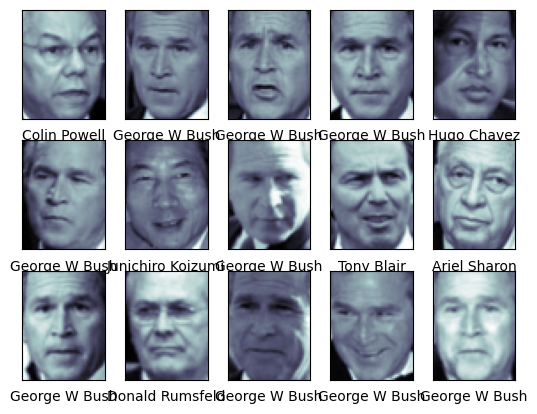

In [71]:
plt.figure(figsize=(20,20))
fig, ax = plt.subplots(3, 5)
for i, axi in enumerate(ax.flat):
    axi.imshow(faces.images[i], cmap='bone')
    axi.set(xticks=[], yticks=[], xlabel=faces.target_names[faces.target[i]])

### Import SVM Classifier

In [72]:
from sklearn.svm import SVC

### Import PCA as RandomizedPCA

In [73]:
from sklearn.decomposition import PCA as RandomizedPCA

<span style='color:red'> **Observation** </span>: RandomizedPCA is just an alias. So far it is the regular PCA. Where will the randomness be implemented?

### Import pipeline

In [75]:
from sklearn.pipeline import make_pipeline

### Build a PCA model with 150 principal components

In [76]:
pca = RandomizedPCA(n_components=150, whiten=True, random_state=42)

In order to implement the randomness, the solver should be set as **'randomized'**. How ever, if the `n_components << min(n_samples, n_features)`, sklearn automatically switch to the randomized solver.

The solver is selected by a default policy based on `X.shape` and
            `n_components`: if the input data is larger than 500x500 and the
            number of components to extract is lower than 80% of the smallest
            dimension of the data, then the more efficient 'randomized'
            method is enabled.

### Build a SVM Classifier with 'rbf' kernel

In [77]:
svc = SVC(kernel='rbf', class_weight='balanced')

### Make a pipeline with pca and svc

In [78]:
pipe_model = make_pipeline(pca, svc)

In [79]:
[m for m in dir(pipe_model) if not m.startswith('_')]

['classes_',
 'decision_function',
 'feature_names_in_',
 'fit',
 'fit_predict',
 'fit_transform',
 'get_feature_names_out',
 'get_params',
 'inverse_transform',
 'memory',
 'n_features_in_',
 'named_steps',
 'predict',
 'predict_log_proba',
 'predict_proba',
 'score',
 'score_samples',
 'set_params',
 'steps',
 'transform',
 'verbose']

#### Pregunta para la clase:
#### Dado que SVM depende de distancias, es muy sencible a la escala. Escalar los datos es prácticamente obligatorio. Por qué no estamos normalizando o escalando los datos aquí?
Los datos de rostros ya están normalizados en el conjunto de datos `faces` (los valores de píxeles están entre 0 y 255).

### Split dataset into train and test 

In [80]:
from sklearn.model_selection import train_test_split
Xtrain, Xtest, ytrain, ytest = train_test_split(faces.data, faces.target, random_state=42)

### Fit the model

In [81]:
pipe_model.fit(Xtrain, ytrain)

Pipeline(steps=[('pca', PCA(n_components=150, random_state=42, whiten=True)),
                ('svc', SVC(class_weight='balanced'))])

### Predict on the testing dataset

In [82]:
ypred = pipe_model.predict(Xtest)

### Plot incorrect labels

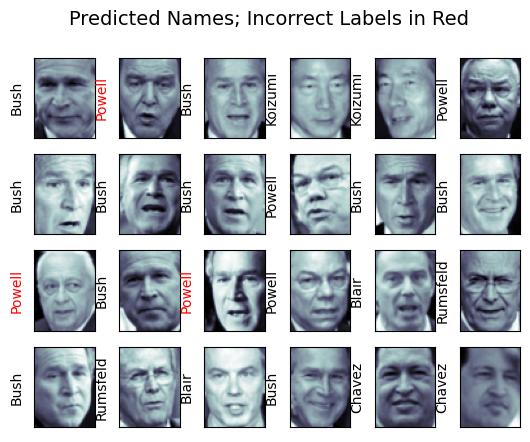

In [83]:
fig, ax = plt.subplots(4, 6)
for i, axi in enumerate(ax.flat):
    axi.imshow(Xtest[i].reshape(62, 47), cmap='bone')
    axi.set(xticks=[], yticks=[])
    axi.set_ylabel(faces.target_names[ypred[i]].split()[-1],
                   color='black' if ypred[i] == ytest[i] else 'red')
fig.suptitle('Predicted Names; Incorrect Labels in Red', size=14);

### Classification Report

In [84]:
from sklearn.metrics import classification_report
print(classification_report(ytest, ypred,
                            target_names=faces.target_names))

                   precision    recall  f1-score   support

     Ariel Sharon       1.00      0.67      0.80        15
     Colin Powell       0.64      0.94      0.76        68
  Donald Rumsfeld       0.93      0.81      0.86        31
    George W Bush       0.92      0.86      0.89       126
Gerhard Schroeder       0.89      0.70      0.78        23
      Hugo Chavez       1.00      0.65      0.79        20
Junichiro Koizumi       1.00      0.75      0.86        12
       Tony Blair       0.88      0.90      0.89        42

         accuracy                           0.84       337
        macro avg       0.91      0.78      0.83       337
     weighted avg       0.87      0.84      0.84       337



### Confusion Matrix

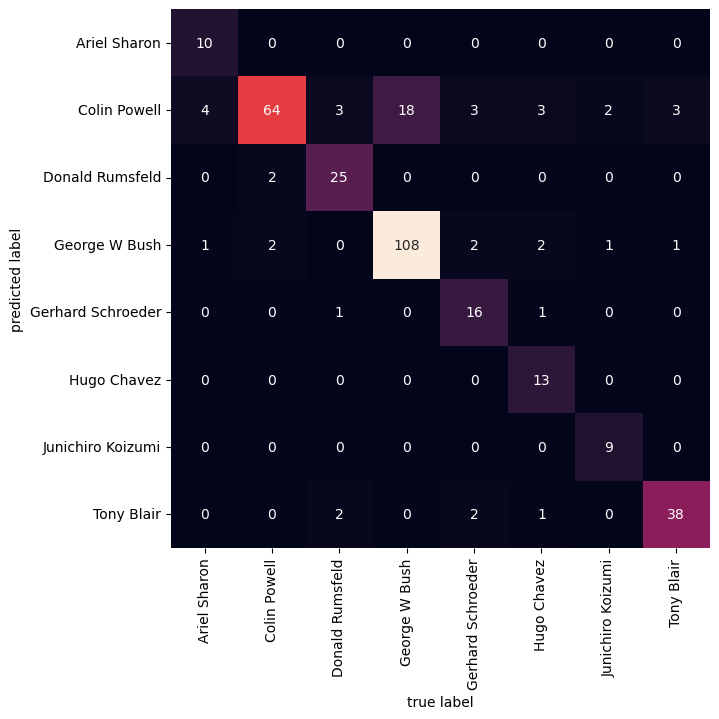

In [85]:
from sklearn.metrics import confusion_matrix
mat = confusion_matrix(ytest, ypred)
plt.figure(figsize=(7,7))
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False,
            xticklabels=faces.target_names,
            yticklabels=faces.target_names)
plt.xlabel('true label')
plt.ylabel('predicted label');

### GridSearchCV
GridSearchCV is a concept where we can try a set of our desired hyperparameter values for hyperparameters and build models with **every combination** of these hyperparameter values and **choose the best model with best hyperparameters** with the maximum accuracy.

### Import GridSearchCV

In [86]:
from sklearn.model_selection import GridSearchCV

In [87]:
[m for m in dir(GridSearchCV) if not m.startswith('_')]

['classes_',
 'decision_function',
 'fit',
 'get_params',
 'inverse_transform',
 'n_features_in_',
 'predict',
 'predict_log_proba',
 'predict_proba',
 'score',
 'score_samples',
 'set_params',
 'transform']

### Set the parameter grid with desired hyperparameters and their values

In [88]:
param_grid = {'svc__C': [1, 5, 10, 50],
              'svc__gamma': [0.0001, 0.0005, 0.001, 0.005]}


### Build the GridSearchCV model by sending the model pipeline and parameter grid

In [89]:
grid = GridSearchCV(pipe_model, param_grid, verbose=1, n_jobs=-1)

#### How many times the model is going to be trained with this GridSearchCV model definition?

Answer: Initially, 4 * 4 = 16 because of the param_grid above. But in addition, the defualt value for cv is 5, so for each set of hyperparameters, the model will be trained 5 times.

That gives a total of <span style='color:yellow'> 16 * 5 = 80 times </span> times. 

In [90]:
[m for m in dir(grid) if not m.startswith('_')]

['classes_',
 'cv',
 'decision_function',
 'error_score',
 'estimator',
 'fit',
 'get_params',
 'inverse_transform',
 'n_features_in_',
 'n_jobs',
 'param_grid',
 'pre_dispatch',
 'predict',
 'predict_log_proba',
 'predict_proba',
 'refit',
 'return_train_score',
 'score',
 'score_samples',
 'scoring',
 'set_params',
 'transform',
 'verbose']

### Fit the model

Let's recall the shape of our data:

In [91]:
Xtrain.shape, ytrain.shape

((1011, 2914), (1011,))

<span style='color:red'> **Observation** </span>: Because PCA is part of the pipeline, the data still has the 2914 features. This necessary to avoid data leak. PCA will be applied at every iteration of the CV just on the training data.

In [92]:
%time grid.fit(Xtrain, ytrain)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


Wall time: 13.7 s


GridSearchCV(estimator=Pipeline(steps=[('pca',
                                        PCA(n_components=150, random_state=42,
                                            whiten=True)),
                                       ('svc', SVC(class_weight='balanced'))]),
             n_jobs=-1,
             param_grid={'svc__C': [1, 5, 10, 50],
                         'svc__gamma': [0.0001, 0.0005, 0.001, 0.005]},
             verbose=1)

In [93]:
[m for m in dir(grid) if not m.startswith('_')]

['best_estimator_',
 'best_index_',
 'best_params_',
 'best_score_',
 'classes_',
 'cv',
 'cv_results_',
 'decision_function',
 'error_score',
 'estimator',
 'fit',
 'get_params',
 'inverse_transform',
 'multimetric_',
 'n_features_in_',
 'n_jobs',
 'n_splits_',
 'param_grid',
 'pre_dispatch',
 'predict',
 'predict_log_proba',
 'predict_proba',
 'refit',
 'refit_time_',
 'return_train_score',
 'score',
 'score_samples',
 'scorer_',
 'scoring',
 'set_params',
 'transform',
 'verbose']

### Best Parameters

In [94]:
grid.best_params_

{'svc__C': 10, 'svc__gamma': 0.001}

<span style='color:red'> **Observation** </span>: The fact that the best value for gamma was the lowest one (0.001), means that the radial basis function (RBF) <span style='color:yellow'> behaved almost as a linear kernel. </span> Hence, the data was linearly separable, as expected, given the large number of dimensions (150).

In [95]:
grid.best_estimator_

Pipeline(steps=[('pca', PCA(n_components=150, random_state=42, whiten=True)),
                ('svc', SVC(C=10, class_weight='balanced', gamma=0.001))])

↑ Useful for the cases in which we have more then 1 estimator

### Choose the best model

In [96]:
grid_estimator = grid.best_estimator_

### Predict on the best chosen model with the best set of hyperparameters

In [97]:
ypred = grid_estimator.predict(Xtest)

### Show some incorrectly predicted images

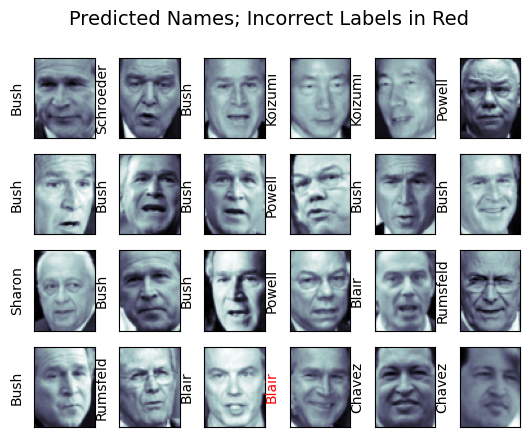

In [98]:
fig, ax = plt.subplots(4, 6)
for i, axi in enumerate(ax.flat):
    axi.imshow(Xtest[i].reshape(62, 47), cmap='bone')
    axi.set(xticks=[], yticks=[])
    axi.set_ylabel(faces.target_names[ypred[i]].split()[-1],
                   color='black' if ypred[i] == ytest[i] else 'red')
fig.suptitle('Predicted Names; Incorrect Labels in Red', size=14);

### Plot Classification Report

In [99]:
from sklearn.metrics import classification_report
print(classification_report(ytest, ypred,
                            target_names=faces.target_names))

                   precision    recall  f1-score   support

     Ariel Sharon       0.65      0.73      0.69        15
     Colin Powell       0.80      0.87      0.83        68
  Donald Rumsfeld       0.74      0.84      0.79        31
    George W Bush       0.92      0.83      0.88       126
Gerhard Schroeder       0.86      0.83      0.84        23
      Hugo Chavez       0.93      0.70      0.80        20
Junichiro Koizumi       0.92      1.00      0.96        12
       Tony Blair       0.85      0.95      0.90        42

         accuracy                           0.85       337
        macro avg       0.83      0.84      0.84       337
     weighted avg       0.86      0.85      0.85       337



### Plot Confusion Matrix

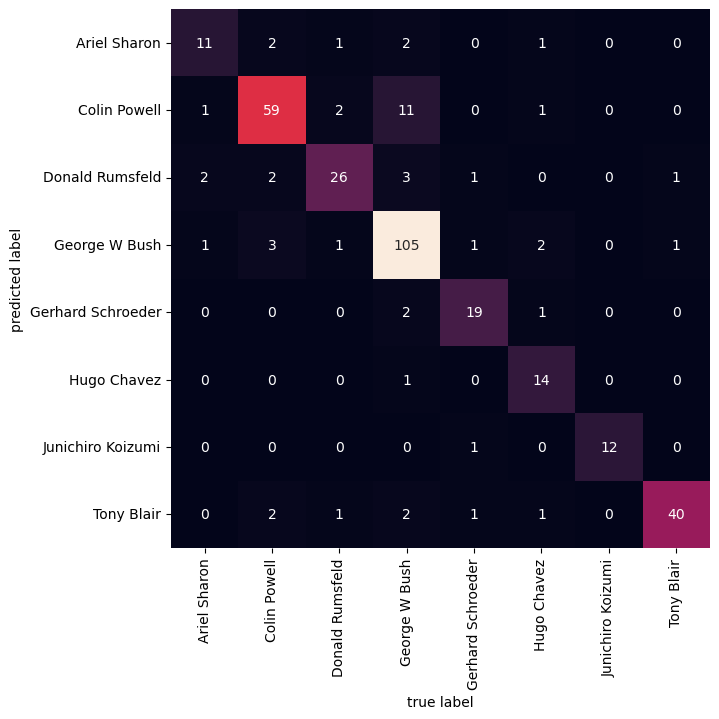

In [100]:
from sklearn.metrics import confusion_matrix
mat = confusion_matrix(ytest, ypred)
plt.figure(figsize=(7,7))
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False,
            xticklabels=faces.target_names,
            yticklabels=faces.target_names)
plt.xlabel('true label')
plt.ylabel('predicted label');